<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/21_09_MduloII_RedesNaurais_Multiclasse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carregamento do Dataset com Montagem de Drive - Fashion

In [6]:
# Imprtand as Biblitecas

import os # Manipulação de arquivs e pastas
import pandas as pd
import numpy as np

# TensorFlow será utilizado para construir e treinar nossa rede
# neural.

import tensorflow as tf

# Keras facilita a criação das redes neurais.

# Bibliteca utiliza para vizalizar imagens e gráficos.
import matplotlib.pyplot as plt

# Biblioteca utilizada para vizualizar imagens e gráficos.
from sklearn.model_selection import train_test_split

In [8]:
# ==========================================
# FORMA 1 - MONTANDO O GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount("/content/drive")

# ==========================================
# LOCALIZANDO OS ARQUIVOS
# ==========================================

train = pd.read_csv("/content/sample_data/mnist_train_small.csv")
test = pd.read_csv("/content/sample_data/mnist_test.csv")

# Visualizando os DataFrames estruturados
display(train.head())
display(test.head())

Mounted at /content/drive


,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Visualizando os DataFrames estruturados
display(train.head())
display(test.head())

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# ============================================================
# PREPARAÇÃO DOS DADOS (X e y)
# ============================================================

X_train_full = train.iloc[:, 1:].values
y_train_full = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

In [12]:
# 1. Normalização: Transforma os valores dos pixels para [0.0, 1.0]

X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

In [13]:
# 2. Divisão de Validação: Separa 20% do treino para monitorar o
# aprendizado

X_train, X_val, y_train, y_val = train_test_split(
X_train_full, y_train_full, test_size=0.2, random_state=42,
stratify=y_train_full
)
print(f"Dados de Treino: {X_train.shape}")
print(f"Dados de Validação: {X_val.shape}")
print(f"Dados de Teste: {X_test.shape}")

Dados de Treino: (15999, 784)
Dados de Validação: (4000, 784)
Dados de Teste: (9999, 784)


In [16]:
import tensorflow as tf

# ============================================================
# CONSTRUÇÃO DA REDE NEURAL DENSA (MLP COM DROPOUT)
# ============================================================

model = tf.keras.Sequential ([
tf.keras.layers.Input(shape=(784,)),
tf.keras.layers.Dense(256, activation="relu"),
tf.keras.layers.Dropout(0.3), # Dropout de 30% para desativar
# neurônios aleatórios no treino
tf.keras.layers.Dense(128, activation="relu"),
tf.keras.layers.Dropout(0.3), # Dropout de 30% na segunda camada
# oculta
tf.keras.layers.Dense(10, activation="softmax")
])

In [17]:
# Compilação do Modelo

model.compile(
optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# CONFIGURAÇÃO DO EARLY STOPPING
# ============================================================
# O callback vai monitorar a perda na validação. Se ela não melhorar
#por 5 épocas,
# o treino para e recupera os pesos da melhor época atingida.

early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=5,
restore_best_weights=True,
verbose=1
)

In [21]:
# ============================================================
# TREINAMENTO DO MODELO (100 ÉPOCAS)
# ============================================================

print("Iniciando o treinamento com Early Stopping...")
history = model.fit(
X_train, y_train,
epochs=100, # Definido para o máximo de 100 épocas
batch_size=64,
validation_data=(X_val, y_val),
callbacks=[early_stopping] # Ativando o monitoramento do Early
# Stopping

)

Iniciando o treinamento com Early Stopping...
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8211 - loss: 0.5802 - val_accuracy: 0.9225 - val_loss: 0.2601
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9261 - loss: 0.2516 - val_accuracy: 0.9408 - val_loss: 0.1971
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9441 - loss: 0.1841 - val_accuracy: 0.9488 - val_loss: 0.1654
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9557 - loss: 0.1472 - val_accuracy: 0.9540 - val_loss: 0.1438
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9627 - loss: 0.1199 - val_accuracy: 0.9592 - val_loss: 0.1394
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9676 - loss: 0.1067 - val_accuracy: 0.9588 - val_loss: 0.1376
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9729 - loss: 0.0854 - val_accuracy: 0.9597 - val_loss: 0.1361
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/

In [22]:
# ============================================================
# AVALIAÇÃO FINAL NO DATASET DE TESTE
# ============================================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nAcurácia final no dataset de teste: {test_acc*100:.2f}%")

# ============================================================
# HISTÓRICO DE TREINAMENTO (GRÁFICOS)
# ============================================================

plt.figure(figsize=(12, 4))

313/313 - 1s - 3ms/step - accuracy: 0.9694 - loss: 0.1102

Acurácia final no dataset de teste: 96.94%


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

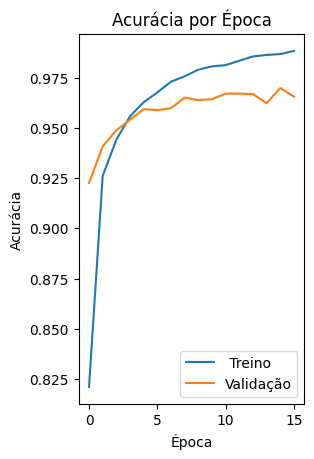

In [23]:
# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label= " Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia por Época")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()

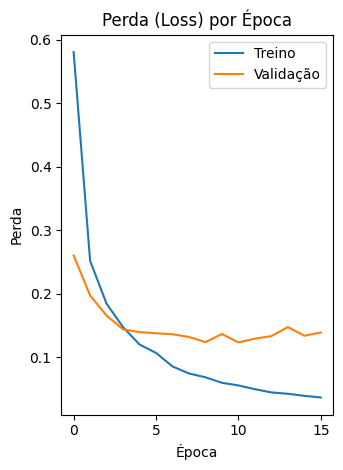

In [24]:
# Gráfico de Perda (Loss)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Perda (Loss) por Época")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.legend()
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


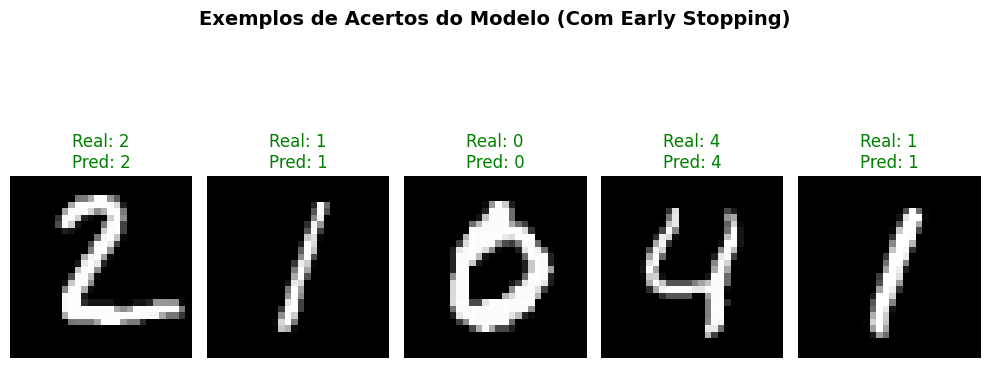

In [26]:
# Plota 5 exemplos de previsões corretas

# Obter previsões do modelo para o conjunto de teste
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Encontrar índices de previsões corretas
indices_corretos = np.where(predicted_labels == y_test)[0]

plt.figure(figsize=(10, 5))
plt.suptitle("Exemplos de Acertos do Modelo (Com Early Stopping)",
fontsize=14, weight="bold")
for i, idx in enumerate(indices_corretos[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Real: {y_test[idx]}\nPred: {predicted_labels[idx]}",
color="green")
    plt.axis("off")
plt.tight_layout()
plt.show()

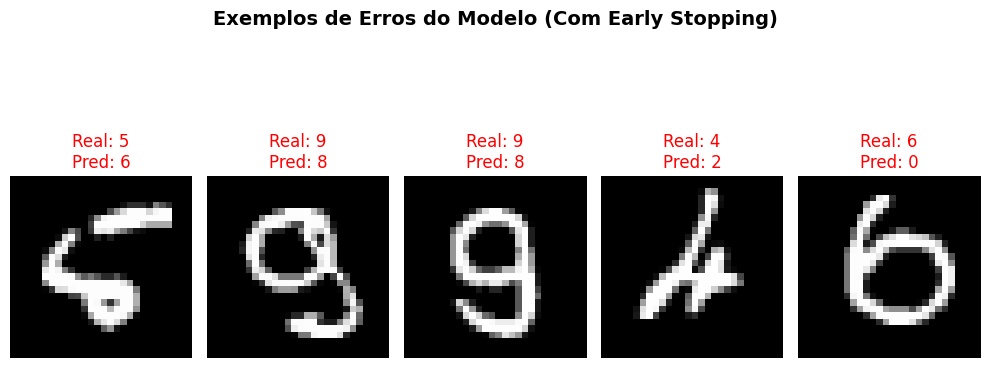

In [29]:
# Plota 5 exemplos de previsões erradas (se houverem)

# Encontrar índices de previsões erradas
indices_errados = np.where(predicted_labels != y_test)[0]

if len(indices_errados) > 0:
    plt.figure(figsize=(10, 5))
    plt.suptitle("Exemplos de Erros do Modelo (Com Early Stopping)",
    fontsize=14, weight="bold")

    for i, idx in enumerate(indices_errados[:5]):
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
        plt.title(f"Real: {y_test[idx]}\nPred: {predicted_labels[idx]}", color="red")
        plt.axis("off")
    plt.tight_layout()
    plt.show()